In [1]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import numpy as np
import pandas as pd
%matplotlib inline

data = t = np.array([[],[]])
poc_hodnoty = tau = np.array([])
poz_clanky = np.array([0, 0.042, 0.084, 0.126, 0.168, 0.21])

delta_x1 = 0.042
def simulacia1(vystup, koef):
    sim = np.zeros_like(t)
    sim[:,0] = poc_hodnoty
    for j in range(1,len(tau)):
        sim[0,j] = t[0,j]
        sim[-1,j] = t[5,j]
        for k in range(1,len(sim)-1):
            delta_tau = tau[j] - tau[j-1]
            sim[k,j] = sim[k,j-1] + delta_tau*koef*(sim[k-1,j-1]-2*sim[k,j-1]+sim[k+1,j-1])/delta_x1**2
    result = sim
    if vystup[0] == 0: 
        result = sim.flatten()
    return result

n_dx = 9
delenie = np.linspace(poz_clanky[0],poz_clanky[-1],n_dx)
delta_x2 = delenie[1] - delenie[0]
def simulacia2(vystup, koef):
    slope, intercept, r, p, stderr = linregress(poz_clanky,poc_hodnoty)
    sim = np.zeros((len(delenie), len(tau)))
    sim[:,0] = np.array([i*slope+intercept for i in delenie])
    for j in range(1,len(tau)):
        sim[0,j] = t[0,j]
        sim[-1,j] = t[5,j]
        for k in range(1,len(sim)-1):
            delta_tau = tau[j] - tau[j-1]
            sim[k,j] = sim[k,j-1] + delta_tau*koef*(sim[k-1,j-1]-2*sim[k,j-1]+sim[k+1,j-1])/delta_x2**2
    if vystup[0] == 0: 
        result = np.zeros_like(t)
        for i, n in zip(poz_clanky, range(0,len(result))):
            result[n,:] = (sim[np.argmin(np.abs(delenie - i)),:])
    return result.flatten()

def podmienka(koef, delta_x, delta_tau):
    if delta_tau>=1/koef*delta_x**2/2:
        print('Podmienka nie je splnená!!! Zmeň n_dx!!!')
    else:  print('Podmienka je splnená.')

def sigma(y_data):
    sigma_rel = 0.0075
    sigma_abs = sigma_rel * np.abs(y_data)
    min_uncertainty = 1e-6
    sigma_abs[np.isclose(sigma_abs, 0)] = min_uncertainty
    return sigma_abs

In [2]:
data = pd.read_csv('data.txt', sep = '\t', decimal=',',header=None)
    
poc_hodnoty = np.array([data[1][0],data[3][0],data[4][0],data[5][0],data[6][0],data[8][0]], dtype=float)
tau = np.array(data[0], dtype=float)
t = np.array([data[1],data[3],data[4],data[5],data[6],data[8]], dtype=float)
delta_tau = tau[-1]/len(tau)

y_data = t.flatten()
popt, pcov = curve_fit(simulacia1, np.zeros_like(y_data), y_data,
                       p0=[1.16e-4],
                       sigma=sigma(y_data),
                       absolute_sigma=True)

perr = np.sqrt(np.diag(pcov))

podmienka(popt[0],delta_x1,delta_tau)

print(popt[0],' ',perr[0])

Podmienka je splnená.
0.00010231892705149956   1.2909879985589512e-09


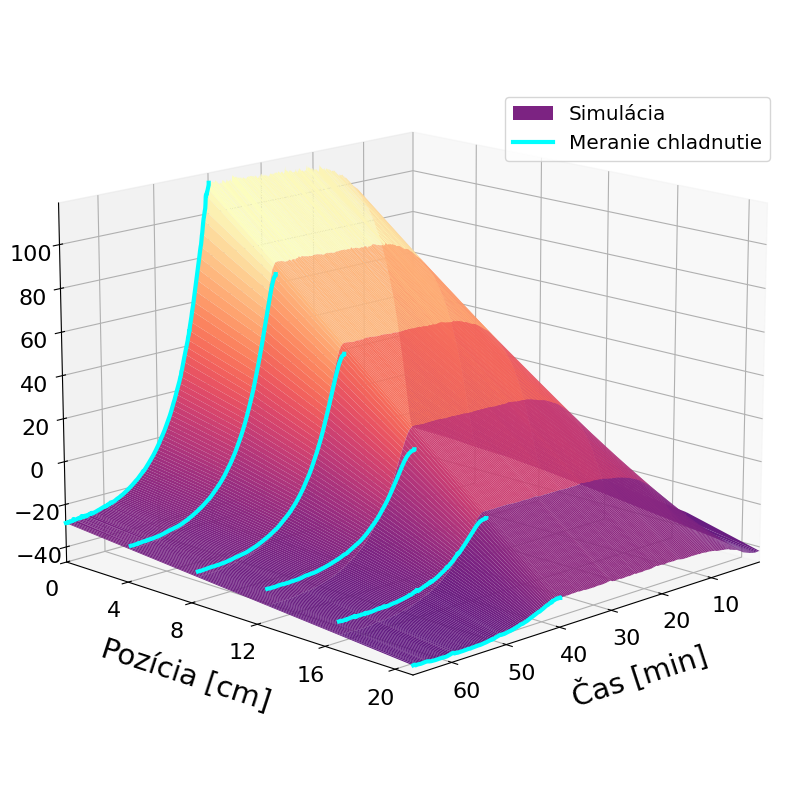

In [3]:
T_grid, X_grid = np.meshgrid(tau/60, poz_clanky*100)
zdata = simulacia1(np.ones_like(y_data),popt[0])

# --- Vytvorenie 3D grafu ---
fig_3d = plt.figure(figsize=(10, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d',computed_zorder=False)

# Vykreslenie povrchu
surf = ax_3d.plot_surface(T_grid, X_grid, zdata*100, cmap='magma',
                          vmin=-100, edgecolor='none', rstride=1, label='Simulácia') 

for i in range(6):
    x = tau[1363:2288] / 60
    y = poz_clanky[i]*100
    z = t[i, 1363:2288] * 100

    ax_3d.plot(x, y, z, color='cyan', linewidth=3)

ax_3d.plot(0, 0, 0, color = 'cyan', linewidth = '3', alpha=1, label='Meranie chladnutie')

# Nastavenie popisov osí a titulu
ax_3d.set_xlabel('Čas [min]', fontsize=21, labelpad=15)
ax_3d.set_ylabel('Pozícia [cm]', fontsize=21, labelpad=15)
ax_3d.set_zlabel('Termonapätie [mV]', fontsize=21, labelpad=15)
ax_3d.tick_params(labelsize=16)
ax_3d.yaxis.set_major_locator(ticker.MultipleLocator(base=4))

ax_3d.set_xlim(tau.max()/60, tau.min()/60)
ax_3d.set_ylim(poz_clanky.max()*100, poz_clanky.min()*100)
ax_3d.view_init(elev=15, azim=-135)
plt.legend(fontsize='x-large',loc='upper right', bbox_to_anchor=(0.99, 0.9))
plt.show()

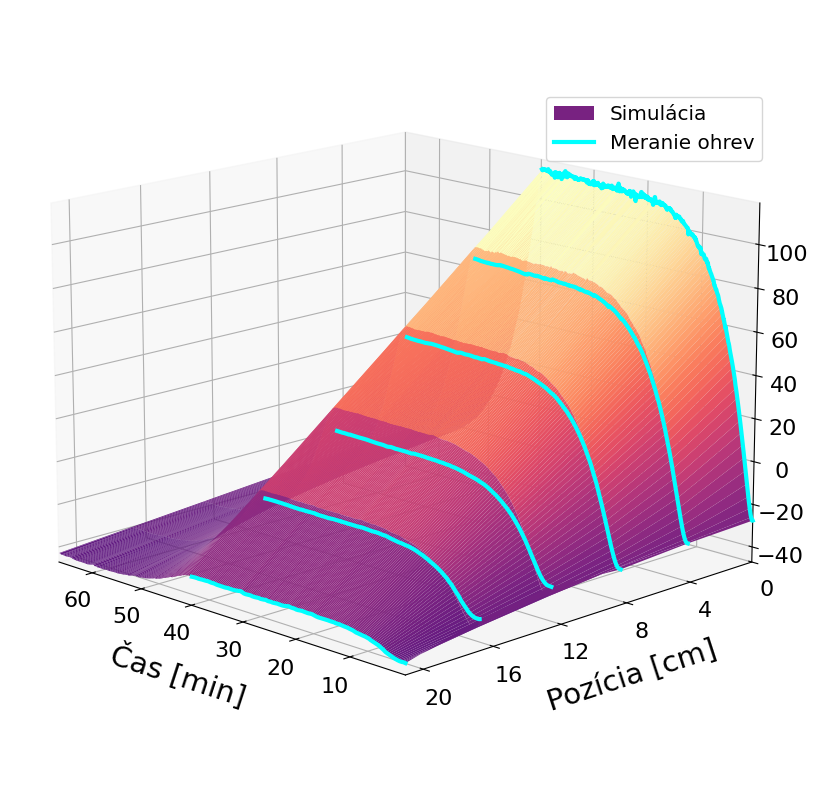

In [4]:
# --- Vytvorenie 3D grafu ---
fig_3d = plt.figure(figsize=(10, 10))

ax_3d = fig_3d.add_subplot(111, projection='3d',computed_zorder=False)

# Vykreslenie povrchu
surf = ax_3d.plot_surface(T_grid, X_grid, zdata*100, cmap='magma',
                          vmin=-100, edgecolor='none', rstride=1, label='Simulácia') 

for i in range(6):
    x = tau[0:1363] / 60
    y = poz_clanky[i]*100
    z = t[i, 0:1363] * 100

    ax_3d.plot(x, y, z, color='cyan', linewidth=3)

ax_3d.plot(0, 0, 0, color = 'cyan', linewidth = '3', alpha=1, label='Meranie ohrev')

# Nastavenie popisov osí a titulu
ax_3d.set_xlabel('Čas [min]', fontsize=21, labelpad=15)
ax_3d.set_ylabel('Pozícia [cm]', fontsize=21, labelpad=15)
ax_3d.set_zlabel('Termonapätie [mV]', fontsize=21, labelpad=15)
ax_3d.tick_params(labelsize=16)
ax_3d.yaxis.set_major_locator(ticker.MultipleLocator(base=4))

ax_3d.set_xlim(tau.max()/60, tau.min()/60)
ax_3d.set_ylim(poz_clanky.max()*100, poz_clanky.min()*100)
ax_3d.view_init(elev=15, azim=-45)

plt.legend(fontsize='x-large',loc='upper right', bbox_to_anchor=(0.99, 0.9))
plt.show()

In [5]:
data = pd.read_csv('chladnutie.txt', sep = '\t', decimal=',',header=None)

poc_hodnoty = np.array([data[1][0],data[3][0],data[4][0],data[5][0],data[6][0],data[8][0]], dtype=float)
tau = np.array(data[0], dtype=float)
t = np.array([data[1],data[3],data[4],data[5],data[6],data[8]], dtype=float)
delta_tau = tau[-1]/len(tau)
y_data = t.flatten()

popt, pcov = curve_fit(simulacia1, np.zeros_like(y_data), y_data,
                       p0=[1.16e-4],
                       sigma=sigma(y_data),
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

podmienka(popt[0],delta_x1,delta_tau)
print(popt[0],' ',perr[0])

Podmienka je splnená.
0.00017049773776735326   9.163998828003925e-09


In [6]:
y_data = t.flatten()
popt, pcov = curve_fit(simulacia2, np.zeros_like(y_data), y_data,
                       p0=[1.16e-4],
                       sigma=sigma(y_data),
                       absolute_sigma=True)

perr = np.sqrt(np.diag(pcov))

podmienka(popt[0],delta_x2,delta_tau)

print(popt[0],' ',perr[0])

Podmienka nie je splnená!!! Zmeň n_dx!!!
0.00012804444240886766   5.024256109533823e-09


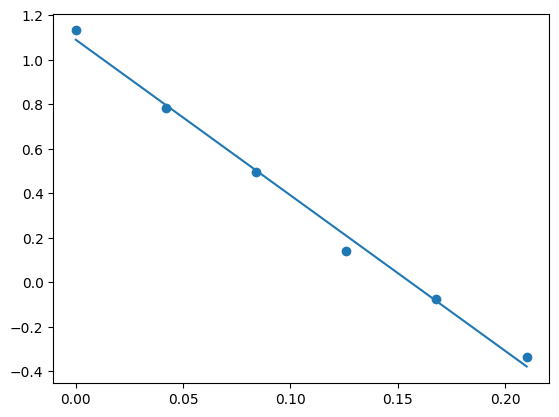

In [7]:
slope, intercept, r, p, stderr = linregress(poz_clanky,poc_hodnoty)

fig, ax = plt.subplots()
ax.scatter(poz_clanky,poc_hodnoty)
ax.plot(poz_clanky,slope*poz_clanky+intercept)
plt.show()